In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

games = pd.read_csv("ID_GPU.csv")
gpu_specs = pd.read_csv("GPU_specs.csv")

print("Games:", games.shape)
print("GPU specifications:", gpu_specs.shape)

display(games.head())
display(gpu_specs.head())

Games: (6783, 17)
GPU specifications: (110, 10)


,AppID,GameName,Release_Date,Peak_CCU,Linux,CCU Rank,Rec_GPU,GPU_Class,GPU_Series,GPU_VRAM,GPU_Performance,GPU_Launch_Year,GPU_MSRP,GPU_PricePerDollar,GPU_Availability,Genre,Genre_Flag
0,380600,Fishing Planet,28/08/2017,2781,True,241,RTX 4060,Mid,GF40,8,75,2023,299,25,Y,Action,N
1,380600,Fishing Planet,28/08/2017,2781,True,241,RTX 4060,Mid,GF40,8,75,2023,299,25,Y,Indie,N
2,380600,Fishing Planet,28/08/2017,2781,True,241,RTX 4060,Mid,GF40,8,75,2023,299,25,Y,Adventure,N
3,380600,Fishing Planet,28/08/2017,2781,True,241,RTX 4060,Mid,GF40,8,75,2023,299,25,Y,Simulation,Y
4,380600,Fishing Planet,28/08/2017,2781,True,241,RTX 4060,Mid,GF40,8,75,2023,299,25,Y,RPG,N


,GPU_Model_Name,Class,Series,VRAM(GB),Performance(%),Launch_Year,Launch MSRP(USD),PricePerDollar,Availability,Unnamed: 9
0,Arc A380,Lower,INT A,6.0,50,1/1/2022,$149,33.56,Y,NaN
1,Arc B570,Mid,INT B,10.0,70,1/1/2025,$219,31.96,Y,NaN
2,RTX 5050,Lower,GF50,8.0,75,1/1/2025,$249,30.12,Y,NaN
3,Arc B580,Mid,INT B,12.0,75,1/1/2024,$249,30.12,Y,NaN
4,RTX 5060,Mid,GF50,8.0,80,1/1/2025,$299,26.76,Y,NaN


In [17]:
games["Release_Date"] = pd.to_datetime(
    games["Release_Date"],
    errors="coerce"
)

genres = ["Action", "Adventure", "RPG"]

modern_games = games[
    (games["Genre"].isin(genres)) &
    (games["Genre_Flag"] == "Y") &
    (games["Release_Date"] >= "2023-01-01") &
    (games["Release_Date"] < "2026-01-01") &
    (games["GPU_Class"].isin(["Mid", "Mid+", "Top", "Top+"])) &
    (games["GPU_Launch_Year"] >= 2018)
].copy()

C:\Users\grand\AppData\Local\Temp\ipykernel_9880\1451287448.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  games["Release_Date"] = pd.to_datetime(


In [18]:
genre_games = (
    modern_games
    .groupby(["AppID", "Genre"], as_index=False)
    .agg(
        Required_Performance=("GPU_Performance", "max"),
        Required_VRAM=("GPU_VRAM", "max"),
        Peak_CCU=("Peak_CCU", "max")
    )
)

print("Unique game-genre records:", len(genre_games))
display(genre_games.head())

Unique game-genre records: 229


,AppID,Genre,Required_Performance,Required_VRAM,Peak_CCU
0,427410,Action,80,8,1458
1,427410,Adventure,80,8,1458
2,427410,RPG,80,8,1458
3,490110,Action,60,6,553
4,513710,Action,60,6,8535


In [19]:
p75_requirements = (
    genre_games
    .groupby("Genre")
    .agg(
        Game_Count=("AppID", "nunique"),
        P75_Performance=(
            "Required_Performance",
            lambda x: x.quantile(0.75)
        ),
        P75_VRAM=(
            "Required_VRAM",
            lambda x: x.quantile(0.75)
        )
    )
    .reset_index()
)

p75_requirements["P75_Performance"] = (
    p75_requirements["P75_Performance"].round(2)
)

p75_requirements["P75_VRAM"] = (
    p75_requirements["P75_VRAM"].round(2)
)

display(p75_requirements)

,Genre,Game_Count,P75_Performance,P75_VRAM
0,Action,94,75.0,10.75
1,Adventure,74,70.0,8.00
2,RPG,61,75.0,12.00


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gpu_specs = pd.read_csv("GPU_Specs.csv")

# Remove empty column
gpu_specs = gpu_specs.drop(columns=["Unnamed: 9"])

# Clean MSRP: "$1,099" → 1099
gpu_specs["Launch MSRP(USD)"] = (
    gpu_specs["Launch MSRP(USD)"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Convert launch year from date string to year
gpu_specs["Launch_Year"] = pd.to_datetime(
    gpu_specs["Launch_Year"],
    errors="coerce"
).dt.year

print(gpu_specs.info())
display(gpu_specs.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GPU_Model_Name    110 non-null    object 
 1   Class             110 non-null    object 
 2   Series            110 non-null    object 
 3   VRAM(GB)          110 non-null    float64
 4   Performance(%)    110 non-null    int64  
 5   Launch_Year       110 non-null    int32  
 6   Launch MSRP(USD)  110 non-null    float64
 7   PricePerDollar    110 non-null    float64
 8   Availability      110 non-null    object 
dtypes: float64(3), int32(1), int64(1), object(4)
memory usage: 7.4+ KB
None


,GPU_Model_Name,Class,Series,VRAM(GB),Performance(%),Launch_Year,Launch MSRP(USD),PricePerDollar,Availability
0,Arc A380,Lower,INT A,6.0,50,2022,149.0,33.56,Y
1,Arc B570,Mid,INT B,10.0,70,2025,219.0,31.96,Y
2,RTX 5050,Lower,GF50,8.0,75,2025,249.0,30.12,Y
3,Arc B580,Mid,INT B,12.0,75,2024,249.0,30.12,Y
4,RTX 5060,Mid,GF50,8.0,80,2025,299.0,26.76,Y


In [21]:
gpu_candidates = gpu_specs[
    (gpu_specs["Performance(%)"] >= 75) &
    (gpu_specs["VRAM(GB)"] >= 11) &
    (gpu_specs["Availability"] == "Y") &
    (gpu_specs["Launch MSRP(USD)"].between(200, 599))
].copy()

gpu_candidates = gpu_candidates.sort_values(
    by="Performance(%)",
    ascending=False
)

display(gpu_candidates)

,GPU_Model_Name,Class,Series,VRAM(GB),Performance(%),Launch_Year,Launch MSRP(USD),PricePerDollar,Availability
33,RX 9070 XT,Mid+,R9000,16.0,90,2025,499.0,18.04,Y
17,RTX 5060 Ti,Mid,GF50,16.0,85,2025,429.0,19.81,Y
38,RX 7900 GRE,Top+,R7000,16.0,85,2024,549.0,15.48,Y
39,RTX 5070,Mid+,GF50,12.0,85,2025,549.0,15.48,Y
40,RX 9070,Mid+,R9000,16.0,85,2025,550.0,15.45,Y
42,RTX 4070 SUPER,Mid+,GF40,12.0,85,2024,599.0,14.19,Y
43,RTX 4070,Mid+,GF40,12.0,85,2023,599.0,14.19,Y
8,RX 9060 XT,Mid,R9000,16.0,80,2025,359.0,22.28,Y
34,RX 7700 XT,Mid+,R7000,12.0,80,2023,449.0,17.82,Y
35,RX 7800 XT,Top,R7000,16.0,80,2023,499.0,16.03,Y


In [22]:
modern_games = games[
    (games["Release_Date"] >= "2023-01-01") &
    (games["Release_Date"] < "2026-01-01") &
    (games["GPU_Class"].isin(["Mid", "Mid+", "Top", "Top+"])) &
    (games["GPU_Launch_Year"] >= 2018)
].copy()

In [23]:
action_games = modern_games[
    modern_games["Genre"] == "Action"
].copy()

In [24]:
performance_stats = (
    genre_games[
        genre_games["Genre"].isin(["Action", "Adventure", "RPG"])
    ]
    .groupby("Genre")["Required_Performance"]
    .agg(
        Mean="mean",
        Median="median",
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        Maximum="max"
    )
    .round(2)
)

display(performance_stats)

,Mean,Median,P75,P90,Maximum
Genre,,,,,
Action,67.50,65.0,75.0,80.0,85
Adventure,65.74,65.0,70.0,78.5,85
RPG,66.64,65.0,75.0,80.0,85


In [25]:
vram_stats = (
    genre_games[
        genre_games["Genre"].isin(["Action", "Adventure", "RPG"])
    ]
    .groupby("Genre")["Required_VRAM"]
    .agg(
        Mean="mean",
        Median="median",
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        Maximum="max"
    )
    .round(2)
)

display(vram_stats)

,Mean,Median,P75,P90,Maximum
Genre,,,,,
Action,8.68,8.0,10.75,12.0,16
Adventure,8.62,8.0,8.00,12.0,16
RPG,8.75,8.0,12.00,12.0,16


In [26]:
action_games = genre_games[
    genre_games["Genre"] == "Action"
].copy()

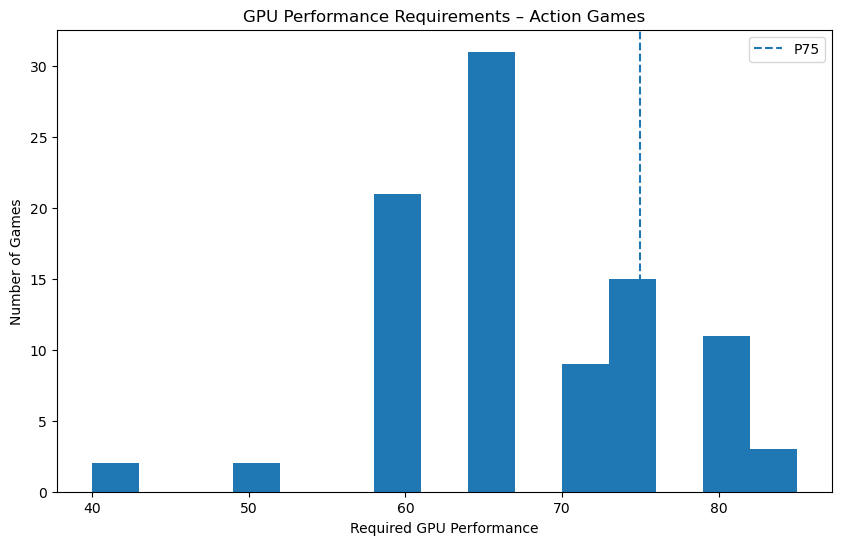

In [27]:
import matplotlib.pyplot as plt

# Filter Action games
action_games = genre_games[
    genre_games["Genre"] == "Action"
].copy()

# Plot histogram
plt.figure(figsize=(10, 6))

plt.hist(
    action_games["Required_Performance"],
    bins=15
)

# P75 line
plt.axvline(
    action_games["Required_Performance"].quantile(0.75),
    linestyle="--",
    label="P75"
)

plt.xlabel("Required GPU Performance")
plt.ylabel("Number of Games")
plt.title("GPU Performance Requirements – Action Games")

plt.legend()
plt.show()

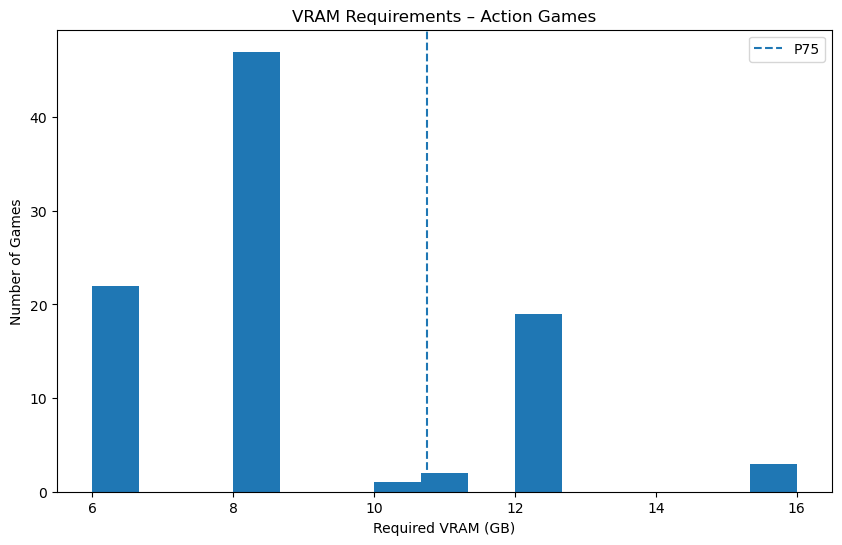

In [28]:
import matplotlib.pyplot as plt

# Histogram for VRAM requirements
plt.figure(figsize=(10, 6))

plt.hist(
    action_games["Required_VRAM"],
    bins=15
)

# P75 line
plt.axvline(
    action_games["Required_VRAM"].quantile(0.75),
    linestyle="--",
    label="P75"
)

plt.xlabel("Required VRAM (GB)")
plt.ylabel("Number of Games")
plt.title("VRAM Requirements – Action Games")

plt.legend()
plt.show()

In [32]:
import numpy as np
import pandas as pd

# Action P75 requirements
action_p75_performance = action_games[
    "Required_Performance"
].quantile(0.75)

action_p75_vram = action_games[
    "Required_VRAM"
].quantile(0.75)

print("Action P75 Performance:", action_p75_performance)
print("Action P75 VRAM:", action_p75_vram)

# Filter candidate GPUs
candidate_gpus = gpu_specs[
    (gpu_specs["Performance(%)"] >= action_p75_performance) &
    (gpu_specs["VRAM(GB)"] >= np.ceil(action_p75_vram)) &
    (gpu_specs["Availability"] == "Y") &
    (gpu_specs["Launch MSRP(USD)"].between(200, 599))
].copy()

candidate_gpus = candidate_gpus.rename(columns={
    "GPU_Model_Name": "Model",
    "Performance(%)": "Performance",
    "VRAM(GB)": "VRAM",
    "Launch MSRP(USD)": "Launch_MSRP"
})

Action P75 Performance: 75.0
Action P75 VRAM: 10.75


In [33]:
metrics = [
    "Performance",
    "VRAM",
    "PricePerDollar"
]

for metric in metrics:

    minimum = candidate_gpus[metric].min()
    maximum = candidate_gpus[metric].max()

    if maximum == minimum:
        candidate_gpus[f"{metric}_Score"] = 1.0
    else:
        candidate_gpus[f"{metric}_Score"] = (
            (candidate_gpus[metric] - minimum) /
            (maximum - minimum)
        )

In [37]:
scenarios = {

    "Balanced": {
        "Performance_Score": 0.30,
        "VRAM_Score": 0.30,
        "PricePerDollar_Score": 0.40
    },

    "Price Sensitive": {
        "Performance_Score": 0.15,
        "VRAM_Score": 0.10,
        "PricePerDollar_Score": 0.75
    },

    "Performance Focused": {
        "Performance_Score": 0.50,
        "VRAM_Score": 0.40,
        "PricePerDollar_Score": 0.10
    }

}

In [38]:
results = []

for scenario, weights in scenarios.items():

    temp = candidate_gpus.copy()

    temp["Fit_Score"] = (
        temp["Performance_Score"] *
        weights["Performance_Score"]

        +

        temp["VRAM_Score"] *
        weights["VRAM_Score"]

        +

        temp["PricePerDollar_Score"] *
        weights["PricePerDollar_Score"]
    )

    temp["Scenario"] = scenario

    results.append(temp)


sensitivity_results = pd.concat(
    results,
    ignore_index=True
)

In [39]:
winners = (
    sensitivity_results
    .sort_values(
        ["Scenario", "Fit_Score"],
        ascending=[True, False]
    )
    .groupby("Scenario")
    .first()
    .reset_index()
)

winners[
    [
        "Scenario",
        "Model",
        "Performance",
        "VRAM",
        "Launch_MSRP",
        "PricePerDollar",
        "Fit_Score"
    ]
]

,Scenario,Model,Performance,VRAM,Launch_MSRP,PricePerDollar,Fit_Score
0,Balanced,RX 9070 XT,90,16.0,499.0,18.04,0.696673
1,Performance Focused,RX 9070 XT,90,16.0,499.0,18.04,0.924168
2,Price Sensitive,Arc B580,75,12.0,249.0,30.12,0.750000
